<a href="https://colab.research.google.com/github/devikasinha/supervised_learning/blob/main/supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json(1) ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json(1)

Saving kaggle.json to kaggle.json
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `cp kaggle.json(1) ~/.kaggle/'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `chmod 600 ~/.kaggle/kaggle.json(1)'


In [ ]:

!kaggle datasets download -d architsharma01/loan-approval-prediction-dataset

import zipfile
with zipfile.ZipFile("loan-approval-prediction-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

Dataset URL: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
License(s): MIT
100% 80.6k/80.6k [00:00<00:00, 734kB/s]



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('loan_approval_dataset.csv')

# --- VIEWING THE RAW DATA ---

print(df.head())  # Shows the first 5 rows

print(df.info())  # Shows column names, non-null counts, and data types

# Cleaning column names and whitespace
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Preprocessing
df = df.drop(columns=['loan_id'])

# --- VIEWING CATEGORICAL DATA BEFORE ENCODING ---

print(df.describe(include=['O']))

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


print(df.head())

# 3. Splitting and Modeling
X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 4. Results
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

Model                | Accuracy
------------------------------
Logistic Regression  | 79.86%
Decision Tree        | 97.54%
Random Forest        | 98.24%
SVM                  | 62.76%
KNN                  | 57.85%
Gradient Boosting    | 97.78%
Naive Bayes          | 77.17%


/tmp/ipykernel_4697/301990716.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


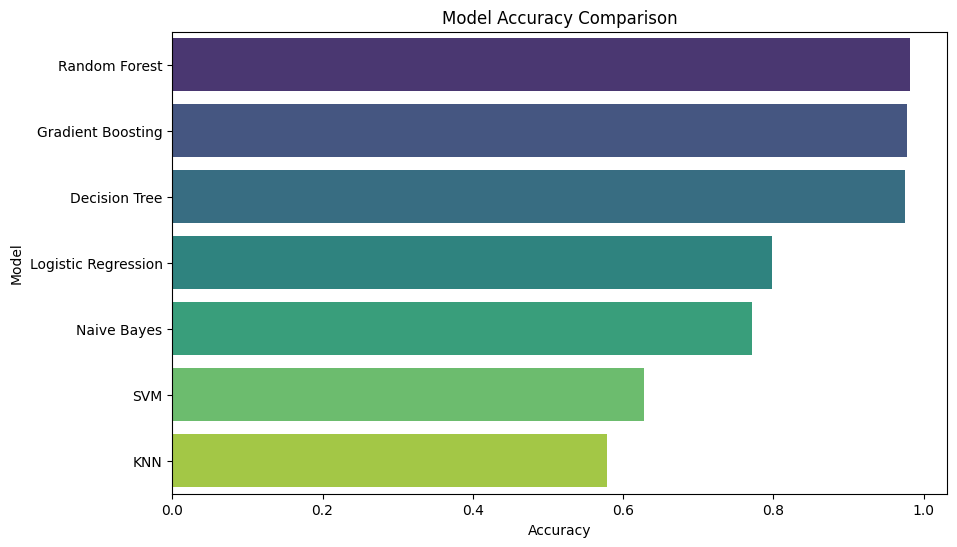

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB()
}

results = []
print(f"{'Model':<20} | {'Accuracy'}")
print("-" * 30)

for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)

    # This line prints the output exactly like your image
    print(f"{name:<20} | {accuracy:.2%}")

    results.append({"Model": name, "Accuracy": accuracy})




import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.show()